### Determinar área de estudio

In [9]:
import geopandas as gpd
from shapely.geometry import Polygon, LineString, box
from matplotlib.colors import ListedColormap
from shapely.ops import polygonize, unary_union
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import json

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import contextily as ctx

from mpl_toolkits.axes_grid1.inset_locator import inset_axes

In [10]:
target_crs = "EPSG:4326"
available_fishing_area = gpd.read_file("./data/available_SWA_fishing_area.geojson")
available_fishing_area = available_fishing_area.to_crs(target_crs)

eez = gpd.read_file("./resources/Marine_Regions/World_EEZ_v12/eez_v12.shp")
eez = eez.to_crs(target_crs)
eez_fk = eez[eez["GEONAME"].str.contains("Falkland", case=False, na=False)]
eez_arg = eez[eez["GEONAME"].str.contains("Argentin", case=False, na=False)]


VMEs = gpd.read_file("../../ARVI-IEO/IEO/RECURSOS/VMEs_ATSW/Categoria_VMEs/Areas_Categoria_VMEs.shp")
VME1 = VMEs[(VMEs["ID_area"] == 3) & (VMEs["Label"] == 1)]
VME1 = VME1.to_crs(target_crs)

fishing = xr.open_dataset("./data/processed/targets/HKP_0.1.nc")
mask = xr.open_dataset("./data/processed/static/fishing_area_mask_0.1.nc")
area_pesca = xr.open_dataset("./data/processed/static/area_pesca_0.1.nc")


<Axes: >

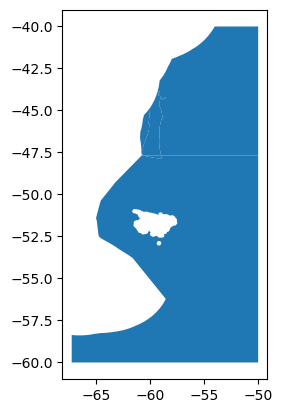

In [11]:
west_geom = unary_union(available_fishing_area.geometry)
east_geom = unary_union(VME1.geometry)

west_boundary = west_geom.boundary
east_boundary = east_geom.boundary

# -----------------------------
# Latitude limits
# -----------------------------
p_fk_north=eez_fk.total_bounds[3]
south_lat = p_fk_north
north_lat = -40
# -----------------------------------
# Get overall longitude extent
# (large enough to cross both boundaries)
# -----------------------------------
minx = min(west_geom.bounds[0], east_geom.bounds[0]) - 10
maxx = max(west_geom.bounds[2], east_geom.bounds[2]) + 10

# -----------------------------------
# Create horizontal latitude lines
# -----------------------------------
south_line = LineString([
    (minx, south_lat),
    (maxx, south_lat)])

north_line = LineString([
    (minx, north_lat),
    (maxx, north_lat)])

# -----------------------------------
# Merge all lines together
# -----------------------------------
all_lines = unary_union([
    west_boundary,
    east_boundary,
    south_line,
    north_line])

# -----------------------------------
# Polygonize closed regions
# -----------------------------------
polygons = list(polygonize(all_lines))

# -----------------------------------
# Convert to GeoDataFrame
# -----------------------------------
gdf_polys = gpd.GeoDataFrame(
    geometry=polygons,
    crs=target_crs)

lat_box = Polygon([
    (minx, south_lat),
    (maxx, south_lat),
    (maxx, north_lat),
    (minx, north_lat)
])

gdf_polys = gdf_polys[gdf_polys.intersects(lat_box)]

gdf_polys.plot()


In [12]:
# Determinar el bounding box para descargar parametros medioambientales. 
min_lon, min_lat, max_lon, max_lat =[-66.0, -57.0, -52.0, -40.0]  #son a ojo basandome en el mapa para descargar de Marine copernicus
print("download bounding box:" f"[{min_lon}, {min_lat}, {max_lon}, {max_lat}]")
download_bbox = {
    "min_lon": min_lon,
    "min_lat": min_lat,
    "max_lon": max_lon,
    "max_lat": max_lat
}

# Save to JSON file
with open("./data/download_bbox.json", "w") as f:
    json.dump(download_bbox, f, indent=4)

download bounding box:[-66.0, -57.0, -52.0, -40.0]


Fishing Bounding box: [-61.0, -47.5, -60.0, -44.875]


<Axes: >

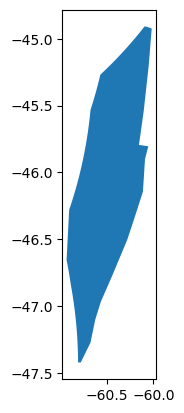

In [13]:
study_area = gdf_polys.iloc[[1]]
study_area_m = study_area.to_crs("EPSG:3857")
cleaned = study_area_m.buffer(-2000).buffer(2000) # buffer to cut weird shapes
poly = cleaned.iloc[0].geoms[0]


cleaned = gpd.GeoSeries([poly], crs="EPSG:3857")
cleaned = cleaned.to_crs(target_crs)
minx, southest_lat, maxx, northest_lat = cleaned.iloc[0].bounds
lat_box = box(minx, southest_lat, maxx,northest_lat)
limited_geom = study_area.geometry.iloc[0].intersection(lat_box)
limited_gdf = gpd.GeoDataFrame(
    geometry=[limited_geom],
    crs=target_crs)



min_lon, min_lat, max_lon, max_lat = limited_gdf.total_bounds
step = 0.125
min_lon = (round(min_lon / step) * step)-0*step
min_lat = (round(min_lat / step) * step)-1*step
max_lon = (round(max_lon / step) * step)+0*step
max_lat = (round(max_lat / step) * step)+0*step
print(f"Fishing Bounding box: [{min_lon}, {min_lat}, {max_lon}, {max_lat}]")

limited_gdf.plot()


In [14]:
# Guardar para crear las mascaras
buffer_010 = limited_gdf.copy()
buffer_010['geometry'] = limited_gdf.geometry.buffer(0.1)
# buffer_010.to_file("./data/area_pesca_0.1.geojson", driver="GeoJSON")

buffer_0125 = limited_gdf.copy()
buffer_0125['geometry'] = limited_gdf.geometry.buffer(0.125)
# buffer_0125.to_file("./data/area_pesca_0.125.geojson", driver="GeoJSON")

C:\Users\rubar\AppData\Local\Temp\ipykernel_26048\1194695016.py:3: UserWarning: Geometry is in a geographic CRS. Results from 'buffer' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  buffer_010['geometry'] = limited_gdf.geometry.buffer(0.1)
C:\Users\rubar\AppData\Local\Temp\ipykernel_26048\1194695016.py:7: UserWarning: Geometry is in a geographic CRS. Results from 'buffer' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  buffer_0125['geometry'] = limited_gdf.geometry.buffer(0.125)


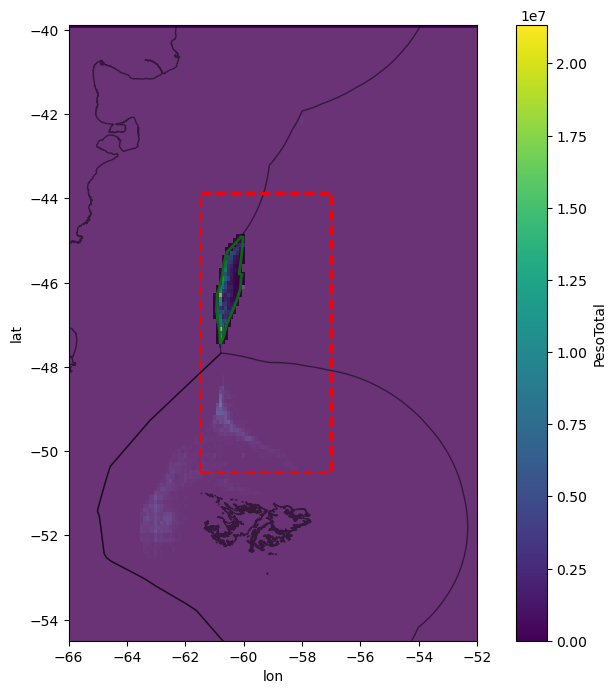

Enviromental bounding box:[-61.5, -50.5, -57.0, -43.875]


In [19]:
fig, ax = plt.subplots(figsize=(10, 8))

# Fishing raster
fishing["PesoTotal"].sum(dim="time").plot(
    ax=ax,
    cmap="viridis"
)

area_pesca["mask"].plot(
    ax=ax,
    add_colorbar=False,
    cmap="Grays",
    alpha=0.2
)

eez_arg.plot(
    ax=ax,
    alpha=0.5,
    facecolor="none",
)

# MVE polygon
limited_gdf = limited_gdf.to_crs("EPSG:4326")

limited_gdf.plot(
    ax=ax,
    facecolor="none",
    edgecolor="green",
    linewidth=2,
    alpha=0.8
)
#self.min_lon, self.min_lat, self.max_lon, self.max_lat = [-61.0 - 0.5, -47.5 - 4, -60.0 + 2, -44.875 + 1]
# Define rectangle parameters
rect_min_lon,  rect_max_lon, rect_min_lat, rect_max_lat = [min_lon-0.5, max_lon+3, min_lat-3, max_lat+1]
x0 = rect_min_lon
y0 = rect_min_lat
width  = rect_max_lon - rect_min_lon
height = rect_max_lat - rect_min_lat

# Create and add the rectangle
rect = Rectangle(
    (x0, y0), width, height,
    linewidth=2, edgecolor='red', facecolor='none', linestyle='--'
)

ax.add_patch(rect)
# Apply limits to the entire axes
ax.set_xlim(min_lon-5, max_lon+8)
ax.set_ylim(min_lat-7, max_lat+5)

plt.show()


print("Enviromental bounding box:" f"[{rect_min_lon}, {rect_min_lat}, {rect_max_lon}, {rect_max_lat}]")
enviroment_bbox = {
    "min_lon": rect_min_lon,
    "min_lat": rect_min_lat,
    "max_lon": rect_max_lon,
    "max_lat": rect_max_lat}

# Save to JSON file
with open("./data/enviroment_bbox.json", "w") as f:
    json.dump(enviroment_bbox, f, indent=4)



C:\Users\rubar\AppData\Local\Temp\ipykernel_26048\495772613.py:272: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


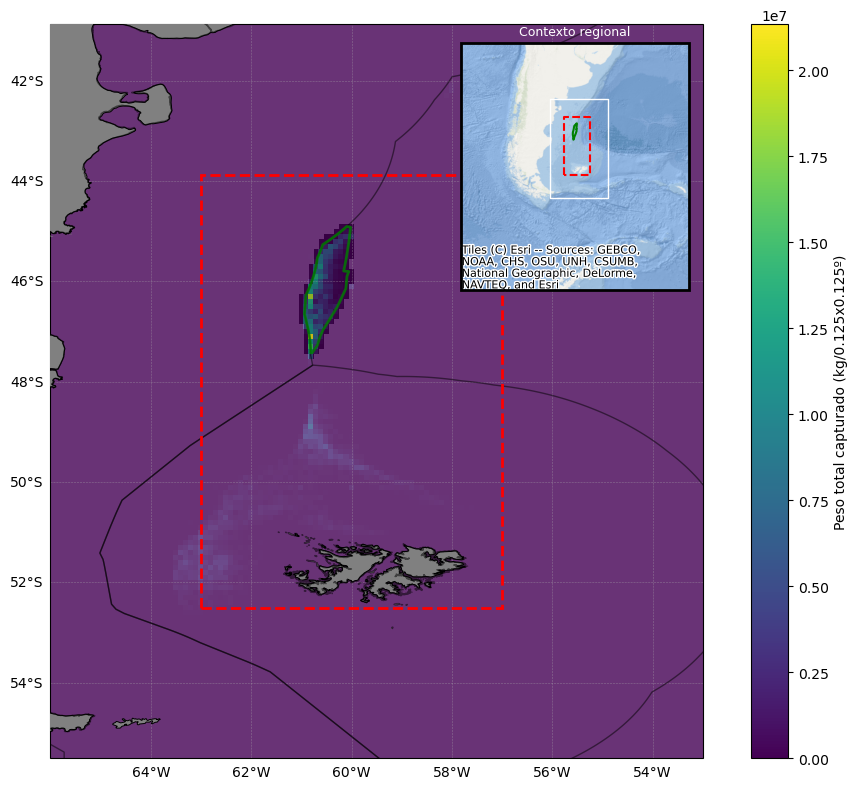

In [16]:
# ----------------------------
# CRS setup
# ----------------------------
crs_lonlat = "EPSG:4326"
crs_web = "EPSG:3857"
map_crs = ccrs.PlateCarree()

eez_arg = eez_arg.to_crs(crs_lonlat)
limited_gdf = limited_gdf.to_crs(crs_lonlat)


# ----------------------------
# Extents
# ----------------------------
rect_min_lon, rect_max_lon, rect_min_lat, rect_max_lat = [
    min_lon - 2,
    max_lon + 3,
    min_lat - 5,
    max_lat + 1,
]

main_extent = [
    min_lon - 5,
    max_lon + 7,
    min_lat - 8,
    max_lat + 4,
]

# More zoomed-out extent for inset
inset_extent_lonlat = [
    min_lon - 25,
    max_lon + 25,
    min_lat - 18,
    max_lat + 14,
]


# ----------------------------
# Main Cartopy plot
# ----------------------------
fig, ax = plt.subplots(
    figsize=(10, 8),
    subplot_kw={"projection": map_crs}
)

ax.set_extent(main_extent, crs=map_crs)

# Ocean background
ax.set_facecolor("#dceefa")


# ----------------------------
# Main raster layers
# ----------------------------

# Fishing raster
fishing["PesoTotal"].sum(dim="time").plot(
    ax=ax,
    cmap="viridis",
    transform=map_crs,
    zorder=1,
    cbar_kwargs={
        "label": "Peso total capturado (kg/0.125x0.125º)"
    }
)

# Fishing area mask
area_pesca["mask"].plot(
    ax=ax,
    add_colorbar=False,
    cmap="Grays",
    alpha=0.2,
    transform=map_crs,
    zorder=2
)


# ----------------------------
# Cartopy land on top of raster
# ----------------------------
land = cfeature.NaturalEarthFeature(
    category="physical",
    name="land",
    scale="10m",
    facecolor="gray",
    edgecolor="none"
)

ax.add_feature(land, zorder=3)

ax.add_feature(
    cfeature.COASTLINE.with_scale("10m"),
    linewidth=0.7,
    edgecolor="black",
    zorder=4
)

ax.add_feature(
    cfeature.BORDERS.with_scale("10m"),
    linewidth=0.4,
    edgecolor="black",
    alpha=0.6,
    zorder=4
)


# ----------------------------
# Vector overlays
# ----------------------------

# EEZ polygon
ax.add_geometries(
    eez_arg.geometry,
    crs=map_crs,
    facecolor="none",
    edgecolor="black",
    linewidth=1,
    alpha=0.5,
    zorder=6
)

# MVE polygon
ax.add_geometries(
    limited_gdf.geometry,
    crs=map_crs,
    facecolor="none",
    edgecolor="green",
    linewidth=2,
    alpha=0.8,
    zorder=7
)

# Red rectangle
rect = Rectangle(
    (rect_min_lon, rect_min_lat),
    rect_max_lon - rect_min_lon,
    rect_max_lat - rect_min_lat,
    linewidth=2,
    edgecolor="red",
    facecolor="none",
    linestyle="--",
    transform=map_crs,
    zorder=8
)

ax.add_patch(rect)


# ----------------------------
# Gridlines
# ----------------------------
gl = ax.gridlines(
    draw_labels=True,
    linewidth=0.4,
    alpha=0.5,
    linestyle="--",
    zorder=9
)

gl.top_labels = False
gl.right_labels = False


# ----------------------------
# Inset ESRI OceanBasemap plot
# ----------------------------
axins = inset_axes(
    ax,
    width="35%",
    height="35%",
    loc="upper right",
    borderpad=1
)

# Create inset extent box in lon/lat, then convert to Web Mercator
inset_box = gpd.GeoDataFrame(
    geometry=[
        box(
            inset_extent_lonlat[0],
            inset_extent_lonlat[2],
            inset_extent_lonlat[1],
            inset_extent_lonlat[3],
        )
    ],
    crs=crs_lonlat
).to_crs(crs_web)

xmin, ymin, xmax, ymax = inset_box.total_bounds

axins.set_xlim(xmin, xmax)
axins.set_ylim(ymin, ymax)

# ESRI Ocean basemap
ctx.add_basemap(
    axins,
    source=ctx.providers.Esri.OceanBasemap,
    crs=crs_web,
    zoom=5
)

# Reproject overlays to Web Mercator for contextily inset
eez_3857 = eez_arg.to_crs(crs_web)
limited_3857 = limited_gdf.to_crs(crs_web)

main_box_3857 = gpd.GeoDataFrame(
    geometry=[
        box(
            main_extent[0],
            main_extent[2],
            main_extent[1],
            main_extent[3],
        )
    ],
    crs=crs_lonlat
).to_crs(crs_web)

rect_box_3857 = gpd.GeoDataFrame(
    geometry=[
        box(
            rect_min_lon,
            rect_min_lat,
            rect_max_lon,
            rect_max_lat,
        )
    ],
    crs=crs_lonlat
).to_crs(crs_web)

# Inset MVE polygon
limited_3857.plot(
    ax=axins,
    facecolor="none",
    edgecolor="green",
    linewidth=1.5
)

# Inset red rectangle
rect_box_3857.boundary.plot(
    ax=axins,
    edgecolor="red",
    linewidth=1.5,
    linestyle="--"
)

# Inset main-map extent
main_box_3857.boundary.plot(
    ax=axins,
    edgecolor="white",
    linewidth=1.0,
    linestyle="-"
)

axins.set_axis_off()
axins.set_title("Contexto regional", fontsize=9, color="white")
# Borde negro alrededor del mapa de contexto
inset_border = Rectangle(
    (0, 0), 1, 1,
    transform=axins.transAxes,
    fill=False,
    edgecolor="black",
    linewidth=2,
    zorder=1000,
    clip_on=False
)

axins.add_patch(inset_border)


# ----------------------------
# Final layout
# ----------------------------
plt.tight_layout()
plt.show()